In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv(r"C:\Users\Moham\Desktop\Projects\weatherAUS-rain-analysis-and-prediction\weatherAUS.csv")
df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [3]:
df.shape

(145460, 23)

In [4]:
pd.set_option('display.max_columns', None)
df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,WNW,20.0,24.0,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,WSW,4.0,22.0,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,WSW,19.0,26.0,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,E,11.0,9.0,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,NW,7.0,20.0,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


# First EDA
## general info about the data

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  str    
 1   Location       145460 non-null  str    
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  str    
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  str    
 10  WindDir3pm     141232 non-null  str    
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null   float64


## statistical info about the data

In [6]:
df.describe()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm
count,143975.000000,144199.000000,142199.000000,82670.000000,75625.000000,135197.000000,143693.000000,142398.000000,142806.000000,140953.000000,130395.00000,130432.000000,89572.000000,86102.000000,143693.000000,141851.00000
mean,12.194034,23.221348,2.360918,5.468232,7.611178,40.035230,14.043426,18.662657,68.880831,51.539116,1017.64994,1015.255889,4.447461,4.509930,16.990631,21.68339
std,6.398495,7.119049,8.478060,4.193704,3.785483,13.607062,8.915375,8.809800,19.029164,20.795902,7.10653,7.037414,2.887159,2.720357,6.488753,6.93665
min,-8.500000,-4.800000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,980.50000,977.100000,0.000000,0.000000,-7.200000,-5.40000
25%,7.600000,17.900000,0.000000,2.600000,4.800000,31.000000,7.000000,13.000000,57.000000,37.000000,1012.90000,1010.400000,1.000000,2.000000,12.300000,16.60000
50%,12.000000,22.600000,0.000000,4.800000,8.400000,39.000000,13.000000,19.000000,70.000000,52.000000,1017.60000,1015.200000,5.000000,5.000000,16.700000,21.10000
75%,16.900000,28.200000,0.800000,7.400000,10.600000,48.000000,19.000000,24.000000,83.000000,66.000000,1022.40000,1020.000000,7.000000,7.000000,21.600000,26.40000
max,33.900000,48.100000,371.000000,145.000000,14.500000,135.000000,130.000000,87.000000,100.000000,100.000000,1041.00000,1039.600000,9.000000,9.000000,40.200000,46.70000


In [7]:
df.describe(include = "object")

C:\Users\Moham\AppData\Local\Temp\ipykernel_18268\3591357663.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include = "object")


,Date,Location,WindGustDir,WindDir9am,WindDir3pm,RainToday,RainTomorrow
count,145460,145460,135134,134894,141232,142199,142193
unique,3436,49,16,16,16,2,2
top,2013-03-01,Canberra,W,N,SE,No,No
freq,49,3436,9915,11758,10838,110319,110316


## droping target column nulls

In [8]:
df.dropna(subset = "RainTomorrow" , inplace = True)
df

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,WNW,20.0,24.0,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,WSW,4.0,22.0,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,WSW,19.0,26.0,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,E,11.0,9.0,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,NW,7.0,20.0,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145454,2017-06-20,Uluru,3.5,21.8,0.0,NaN,NaN,E,31.0,ESE,E,15.0,13.0,59.0,27.0,1024.7,1021.2,NaN,NaN,9.4,20.9,No,No
145455,2017-06-21,Uluru,2.8,23.4,0.0,NaN,NaN,E,31.0,SE,ENE,13.0,11.0,51.0,24.0,1024.6,1020.3,NaN,NaN,10.1,22.4,No,No
145456,2017-06-22,Uluru,3.6,25.3,0.0,NaN,NaN,NNW,22.0,SE,N,13.0,9.0,56.0,21.0,1023.5,1019.1,NaN,NaN,10.9,24.5,No,No
145457,2017-06-23,Uluru,5.4,26.9,0.0,NaN,NaN,N,37.0,SE,WNW,9.0,9.0,53.0,24.0,1021.0,1016.8,NaN,NaN,12.5,26.1,No,No


## checking

In [9]:
df.shape

(142193, 23)

In [10]:
df.RainTomorrow.isna().sum()

np.int64(0)

In [11]:
df.info()

<class 'pandas.DataFrame'>
Index: 142193 entries, 0 to 145458
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           142193 non-null  str    
 1   Location       142193 non-null  str    
 2   MinTemp        141556 non-null  float64
 3   MaxTemp        141871 non-null  float64
 4   Rainfall       140787 non-null  float64
 5   Evaporation    81350 non-null   float64
 6   Sunshine       74377 non-null   float64
 7   WindGustDir    132863 non-null  str    
 8   WindGustSpeed  132923 non-null  float64
 9   WindDir9am     132180 non-null  str    
 10  WindDir3pm     138415 non-null  str    
 11  WindSpeed9am   140845 non-null  float64
 12  WindSpeed3pm   139563 non-null  float64
 13  Humidity9am    140419 non-null  float64
 14  Humidity3pm    138583 non-null  float64
 15  Pressure9am    128179 non-null  float64
 16  Pressure3pm    128212 non-null  float64
 17  Cloud9am       88536 non-null   float64
 18  

In [12]:
df

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,WNW,20.0,24.0,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,WSW,4.0,22.0,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,WSW,19.0,26.0,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,E,11.0,9.0,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,NW,7.0,20.0,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145454,2017-06-20,Uluru,3.5,21.8,0.0,NaN,NaN,E,31.0,ESE,E,15.0,13.0,59.0,27.0,1024.7,1021.2,NaN,NaN,9.4,20.9,No,No
145455,2017-06-21,Uluru,2.8,23.4,0.0,NaN,NaN,E,31.0,SE,ENE,13.0,11.0,51.0,24.0,1024.6,1020.3,NaN,NaN,10.1,22.4,No,No
145456,2017-06-22,Uluru,3.6,25.3,0.0,NaN,NaN,NNW,22.0,SE,N,13.0,9.0,56.0,21.0,1023.5,1019.1,NaN,NaN,10.9,24.5,No,No
145457,2017-06-23,Uluru,5.4,26.9,0.0,NaN,NaN,N,37.0,SE,WNW,9.0,9.0,53.0,24.0,1021.0,1016.8,NaN,NaN,12.5,26.1,No,No


## reset the index

In [13]:
df.reset_index(drop = True , inplace= True)

In [14]:
df

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,WNW,20.0,24.0,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,WSW,4.0,22.0,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,WSW,19.0,26.0,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,E,11.0,9.0,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,NW,7.0,20.0,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142188,2017-06-20,Uluru,3.5,21.8,0.0,NaN,NaN,E,31.0,ESE,E,15.0,13.0,59.0,27.0,1024.7,1021.2,NaN,NaN,9.4,20.9,No,No
142189,2017-06-21,Uluru,2.8,23.4,0.0,NaN,NaN,E,31.0,SE,ENE,13.0,11.0,51.0,24.0,1024.6,1020.3,NaN,NaN,10.1,22.4,No,No
142190,2017-06-22,Uluru,3.6,25.3,0.0,NaN,NaN,NNW,22.0,SE,N,13.0,9.0,56.0,21.0,1023.5,1019.1,NaN,NaN,10.9,24.5,No,No
142191,2017-06-23,Uluru,5.4,26.9,0.0,NaN,NaN,N,37.0,SE,WNW,9.0,9.0,53.0,24.0,1021.0,1016.8,NaN,NaN,12.5,26.1,No,No


## sorting values and reset the index again

In [15]:
df.sort_values(by = ["Location" , "Date"] , inplace= True)
df.reset_index(drop = True , inplace=True)
df

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-07-01,Adelaide,8.8,15.7,5.0,1.6,2.6,NW,48.0,SW,W,13.0,15.0,92.0,67.0,1017.4,1017.7,NaN,NaN,13.5,14.9,Yes,No
1,2008-07-02,Adelaide,12.7,15.8,0.8,1.4,7.8,SW,35.0,SSW,SW,13.0,15.0,75.0,52.0,1022.4,1022.6,NaN,NaN,13.7,15.5,No,No
2,2008-07-03,Adelaide,6.2,15.1,0.0,1.8,2.1,W,20.0,NNE,SW,2.0,11.0,81.0,56.0,1027.8,1026.5,NaN,NaN,9.3,13.9,No,No
3,2008-07-04,Adelaide,5.3,15.9,0.0,1.4,8.0,NNE,30.0,NNE,NE,6.0,13.0,71.0,46.0,1028.7,1025.6,NaN,NaN,10.2,15.3,No,No
4,2008-07-06,Adelaide,11.3,15.7,NaN,NaN,1.5,NNW,52.0,NNE,NNW,15.0,22.0,62.0,62.0,1019.5,1016.2,NaN,NaN,13.0,14.4,NaN,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142188,2017-06-20,Woomera,5.6,19.7,0.0,2.2,0.0,N,20.0,E,ESE,9.0,7.0,61.0,28.0,1028.1,1025.9,0.0,NaN,11.1,19.2,No,No
142189,2017-06-21,Woomera,5.8,19.9,0.0,2.0,NaN,ENE,22.0,ESE,ESE,11.0,9.0,52.0,22.0,1027.9,1025.1,1.0,NaN,11.1,19.1,No,No
142190,2017-06-22,Woomera,7.8,19.0,0.0,1.4,NaN,NNE,31.0,ENE,NNW,13.0,17.0,48.0,37.0,1025.8,1022.2,8.0,6.0,11.1,18.0,No,No
142191,2017-06-23,Woomera,8.0,22.5,0.0,4.0,NaN,NNW,33.0,N,NW,13.0,15.0,57.0,31.0,1021.0,1018.2,7.0,3.0,11.5,21.5,No,No


## linear interporatoin on smoth columns like mintemp , maxtemp , ....

In [16]:
df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-07-01,Adelaide,8.8,15.7,5.0,1.6,2.6,NW,48.0,SW,W,13.0,15.0,92.0,67.0,1017.4,1017.7,NaN,NaN,13.5,14.9,Yes,No
1,2008-07-02,Adelaide,12.7,15.8,0.8,1.4,7.8,SW,35.0,SSW,SW,13.0,15.0,75.0,52.0,1022.4,1022.6,NaN,NaN,13.7,15.5,No,No
2,2008-07-03,Adelaide,6.2,15.1,0.0,1.8,2.1,W,20.0,NNE,SW,2.0,11.0,81.0,56.0,1027.8,1026.5,NaN,NaN,9.3,13.9,No,No
3,2008-07-04,Adelaide,5.3,15.9,0.0,1.4,8.0,NNE,30.0,NNE,NE,6.0,13.0,71.0,46.0,1028.7,1025.6,NaN,NaN,10.2,15.3,No,No
4,2008-07-06,Adelaide,11.3,15.7,NaN,NaN,1.5,NNW,52.0,NNE,NNW,15.0,22.0,62.0,62.0,1019.5,1016.2,NaN,NaN,13.0,14.4,NaN,Yes


In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 142193 entries, 0 to 142192
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           142193 non-null  str    
 1   Location       142193 non-null  str    
 2   MinTemp        141556 non-null  float64
 3   MaxTemp        141871 non-null  float64
 4   Rainfall       140787 non-null  float64
 5   Evaporation    81350 non-null   float64
 6   Sunshine       74377 non-null   float64
 7   WindGustDir    132863 non-null  str    
 8   WindGustSpeed  132923 non-null  float64
 9   WindDir9am     132180 non-null  str    
 10  WindDir3pm     138415 non-null  str    
 11  WindSpeed9am   140845 non-null  float64
 12  WindSpeed3pm   139563 non-null  float64
 13  Humidity9am    140419 non-null  float64
 14  Humidity3pm    138583 non-null  float64
 15  Pressure9am    128179 non-null  float64
 16  Pressure3pm    128212 non-null  float64
 17  Cloud9am       88536 non-null   float64


In [18]:
df.describe()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm
count,141556.000000,141871.000000,140787.000000,81350.000000,74377.000000,132923.000000,140845.000000,139563.000000,140419.000000,138583.000000,128179.000000,128212.000000,88536.000000,85099.000000,141289.000000,139467.000000
mean,12.186400,23.226784,2.349974,5.469824,7.624853,39.984292,14.001988,18.637576,68.843810,51.482606,1017.653758,1015.258204,4.437189,4.503167,16.987509,21.687235
std,6.403283,7.117618,8.465173,4.188537,3.781525,13.588801,8.893337,8.803345,19.051293,20.797772,7.105476,7.036677,2.887016,2.720633,6.492838,6.937594
min,-8.500000,-4.800000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,980.500000,977.100000,0.000000,0.000000,-7.200000,-5.400000
25%,7.600000,17.900000,0.000000,2.600000,4.900000,31.000000,7.000000,13.000000,57.000000,37.000000,1012.900000,1010.400000,1.000000,2.000000,12.300000,16.600000
50%,12.000000,22.600000,0.000000,4.800000,8.500000,39.000000,13.000000,19.000000,70.000000,52.000000,1017.600000,1015.200000,5.000000,5.000000,16.700000,21.100000
75%,16.800000,28.200000,0.800000,7.400000,10.600000,48.000000,19.000000,24.000000,83.000000,66.000000,1022.400000,1020.000000,7.000000,7.000000,21.600000,26.400000
max,33.900000,48.100000,371.000000,145.000000,14.500000,135.000000,130.000000,87.000000,100.000000,100.000000,1041.000000,1039.600000,9.000000,9.000000,40.200000,46.700000


In [19]:
num_clolumns = df.select_dtypes(include=["number"]).columns

boundaries_list = []

for i in num_clolumns :
    q1 = df[i].quantile(0.25)
    q3 = df[i].quantile(0.75)
    iqr = (q3 - q1)
    upper_boundry = q3 + (1.5 * iqr)
    lower_boundry = q1 - (1.5 * iqr)


    boundaries_list.append ( {
        "colums" : i ,
        "upper_boundry"  : upper_boundry ,
        "lower_boundry"  : lower_boundry } )

boundaries_df = pd.DataFrame(boundaries_list)
boundaries_df




,colums,upper_boundry,lower_boundry
0,MinTemp,30.60,-6.20
1,MaxTemp,43.65,2.45
2,Rainfall,2.00,-1.20
3,Evaporation,14.60,-4.60
4,Sunshine,19.15,-3.65
5,WindGustSpeed,73.50,5.50
6,WindSpeed9am,37.00,-11.00
7,WindSpeed3pm,40.50,-3.50
8,Humidity9am,122.00,18.00
9,Humidity3pm,109.50,-6.50


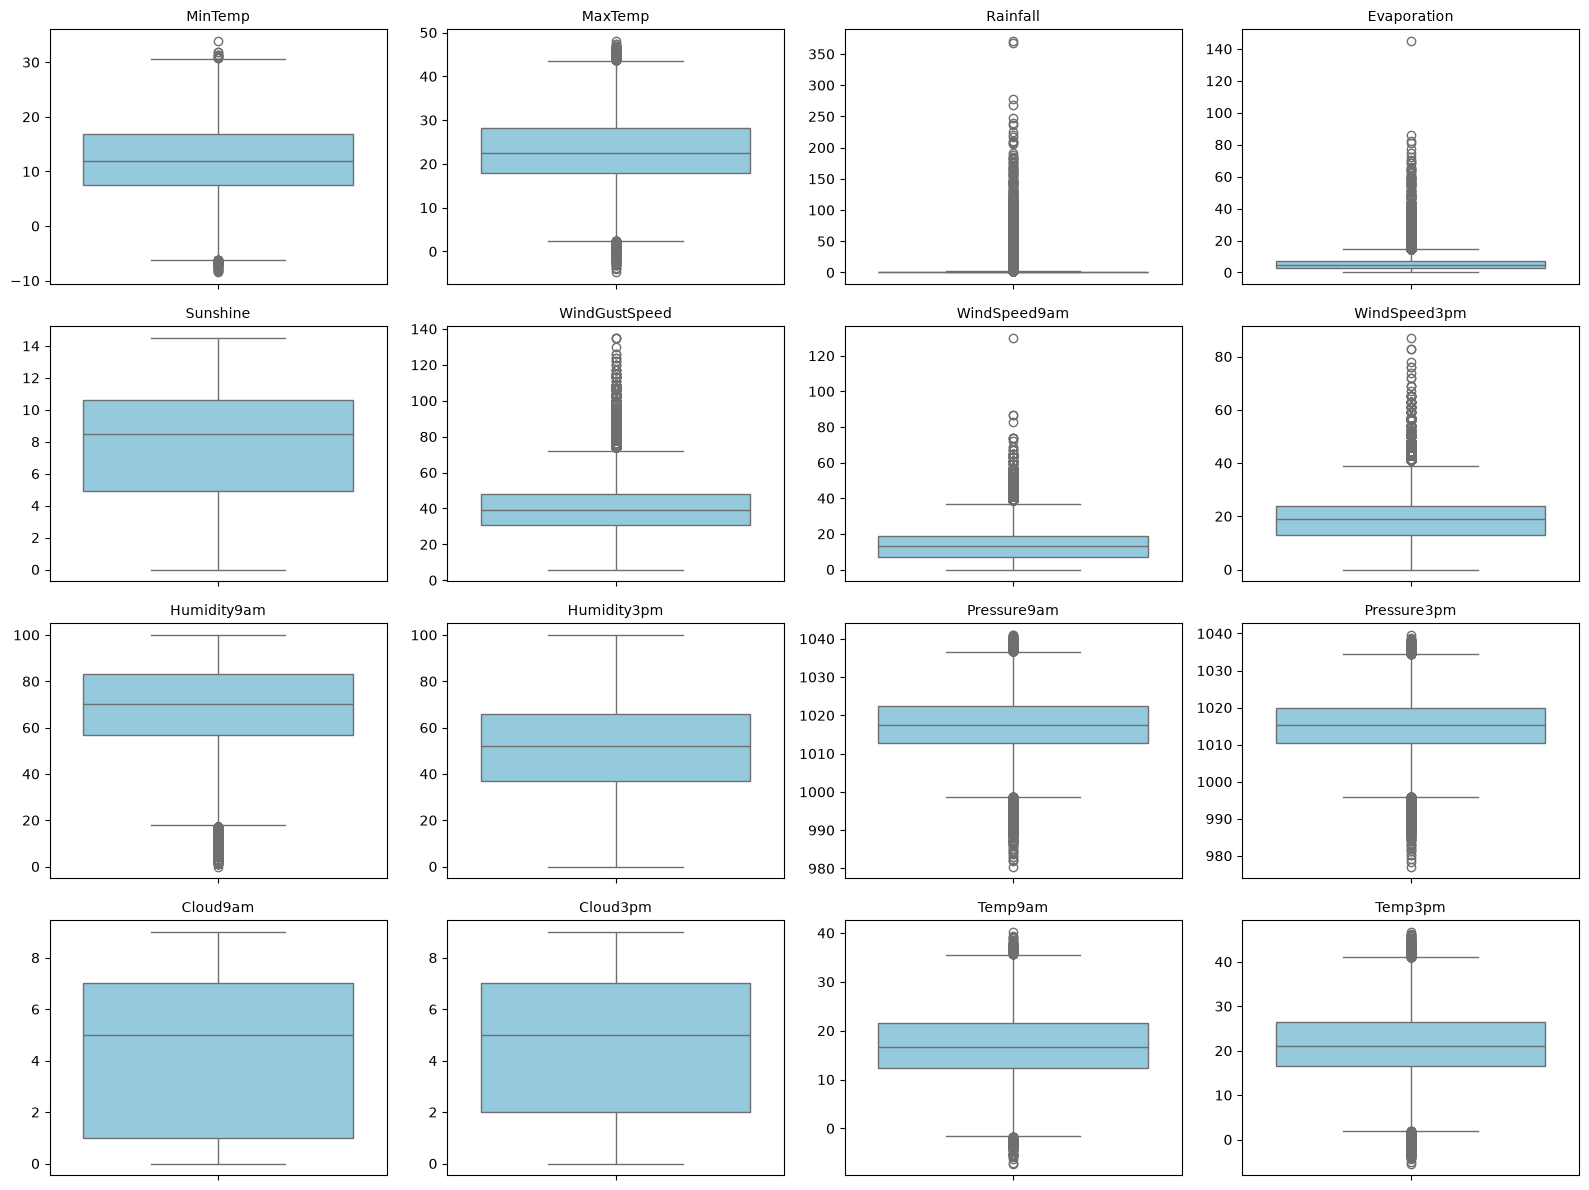

In [20]:
import math

num_cols_count = len(num_clolumns)

n_cols = 4
n_rows = math.ceil(num_cols_count / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3))

axes = axes.flatten()

for i, col in enumerate(num_clolumns):
    sns.boxplot(y=df[col], ax=axes[i], color='skyblue')
    axes[i].set_title(col, fontsize=10)
    axes[i].set_ylabel('')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# 

In [21]:
import pandas as pd

df['Date'] = pd.to_datetime(df['Date'])

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day

def get_season(month):
    if month in [12, 1, 2]:
        return 'Summer'
    elif month in [3, 4, 5]:
        return 'Autumn'
    elif month in [6, 7, 8]:
        return 'Winter'
    else:
        return 'Spring'

df['Season'] = df['Month'].apply(get_season)

df = df.sort_values(by=['Location', 'Date']).reset_index(drop=True)

In [22]:
continuous_cols = ['MinTemp', 'MaxTemp', 'Temp9am', 'Temp3pm', 'Pressure9am', 'Pressure3pm']

for col in continuous_cols:
    df[col] = df.groupby('Location')[col].transform(lambda x: x.interpolate(method='linear', limit_direction='both'))

In [23]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 142193 entries, 0 to 142192
Data columns (total 27 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   Date           142193 non-null  datetime64[us]
 1   Location       142193 non-null  str           
 2   MinTemp        142193 non-null  float64       
 3   MaxTemp        142193 non-null  float64       
 4   Rainfall       140787 non-null  float64       
 5   Evaporation    81350 non-null   float64       
 6   Sunshine       74377 non-null   float64       
 7   WindGustDir    132863 non-null  str           
 8   WindGustSpeed  132923 non-null  float64       
 9   WindDir9am     132180 non-null  str           
 10  WindDir3pm     138415 non-null  str           
 11  WindSpeed9am   140845 non-null  float64       
 12  WindSpeed3pm   139563 non-null  float64       
 13  Humidity9am    140419 non-null  float64       
 14  Humidity3pm    138583 non-null  float64       
 15  Pressure9am

In [24]:
skewed_cols = ['Rainfall', 'Evaporation', 'Sunshine', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Cloud9am', 'Cloud3pm']

for col in skewed_cols:
    df[col] = df.groupby(['Location', 'Year' , 'Month'])[col].transform(lambda x: x.fillna(x.median()))
    df[col] = df[col].fillna(df[col].median())

In [25]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 142193 entries, 0 to 142192
Data columns (total 27 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   Date           142193 non-null  datetime64[us]
 1   Location       142193 non-null  str           
 2   MinTemp        142193 non-null  float64       
 3   MaxTemp        142193 non-null  float64       
 4   Rainfall       142193 non-null  float64       
 5   Evaporation    142193 non-null  float64       
 6   Sunshine       142193 non-null  float64       
 7   WindGustDir    132863 non-null  str           
 8   WindGustSpeed  142193 non-null  float64       
 9   WindDir9am     132180 non-null  str           
 10  WindDir3pm     138415 non-null  str           
 11  WindSpeed9am   142193 non-null  float64       
 12  WindSpeed3pm   142193 non-null  float64       
 13  Humidity9am    142193 non-null  float64       
 14  Humidity3pm    142193 non-null  float64       
 15  Pressure9am

In [26]:
cat_cols = ['WindGustDir', 'WindDir9am', 'WindDir3pm']

for col in cat_cols:
    df[col] = df.groupby('Location')[col].transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else 'Unknown'))

In [27]:
df

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,Year,Month,Day,Season
0,2008-07-01,Adelaide,8.8,15.7,5.0,1.6,2.6,NW,48.0,SW,W,13.0,15.0,92.0,67.0,1017.4,1017.7,6.0,5.0,13.5,14.9,Yes,No,2008,7,1,Winter
1,2008-07-02,Adelaide,12.7,15.8,0.8,1.4,7.8,SW,35.0,SSW,SW,13.0,15.0,75.0,52.0,1022.4,1022.6,6.0,5.0,13.7,15.5,No,No,2008,7,2,Winter
2,2008-07-03,Adelaide,6.2,15.1,0.0,1.8,2.1,W,20.0,NNE,SW,2.0,11.0,81.0,56.0,1027.8,1026.5,6.0,5.0,9.3,13.9,No,No,2008,7,3,Winter
3,2008-07-04,Adelaide,5.3,15.9,0.0,1.4,8.0,NNE,30.0,NNE,NE,6.0,13.0,71.0,46.0,1028.7,1025.6,6.0,5.0,10.2,15.3,No,No,2008,7,4,Winter
4,2008-07-06,Adelaide,11.3,15.7,0.8,1.6,1.5,NNW,52.0,NNE,NNW,15.0,22.0,62.0,62.0,1019.5,1016.2,6.0,5.0,13.0,14.4,NaN,Yes,2008,7,6,Winter
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142188,2017-06-20,Woomera,5.6,19.7,0.0,2.2,0.0,N,20.0,E,ESE,9.0,7.0,61.0,28.0,1028.1,1025.9,0.0,3.5,11.1,19.2,No,No,2017,6,20,Winter
142189,2017-06-21,Woomera,5.8,19.9,0.0,2.0,0.0,ENE,22.0,ESE,ESE,11.0,9.0,52.0,22.0,1027.9,1025.1,1.0,3.5,11.1,19.1,No,No,2017,6,21,Winter
142190,2017-06-22,Woomera,7.8,19.0,0.0,1.4,0.0,NNE,31.0,ENE,NNW,13.0,17.0,48.0,37.0,1025.8,1022.2,8.0,6.0,11.1,18.0,No,No,2017,6,22,Winter
142191,2017-06-23,Woomera,8.0,22.5,0.0,4.0,0.0,NNW,33.0,N,NW,13.0,15.0,57.0,31.0,1021.0,1018.2,7.0,3.0,11.5,21.5,No,No,2017,6,23,Winter


In [28]:
df['RainToday_num'] = df['RainToday'].map({"Yes" : 1 , "No" : 0})

In [29]:
df

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,Year,Month,Day,Season,RainToday_num
0,2008-07-01,Adelaide,8.8,15.7,5.0,1.6,2.6,NW,48.0,SW,W,13.0,15.0,92.0,67.0,1017.4,1017.7,6.0,5.0,13.5,14.9,Yes,No,2008,7,1,Winter,1.0
1,2008-07-02,Adelaide,12.7,15.8,0.8,1.4,7.8,SW,35.0,SSW,SW,13.0,15.0,75.0,52.0,1022.4,1022.6,6.0,5.0,13.7,15.5,No,No,2008,7,2,Winter,0.0
2,2008-07-03,Adelaide,6.2,15.1,0.0,1.8,2.1,W,20.0,NNE,SW,2.0,11.0,81.0,56.0,1027.8,1026.5,6.0,5.0,9.3,13.9,No,No,2008,7,3,Winter,0.0
3,2008-07-04,Adelaide,5.3,15.9,0.0,1.4,8.0,NNE,30.0,NNE,NE,6.0,13.0,71.0,46.0,1028.7,1025.6,6.0,5.0,10.2,15.3,No,No,2008,7,4,Winter,0.0
4,2008-07-06,Adelaide,11.3,15.7,0.8,1.6,1.5,NNW,52.0,NNE,NNW,15.0,22.0,62.0,62.0,1019.5,1016.2,6.0,5.0,13.0,14.4,NaN,Yes,2008,7,6,Winter,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142188,2017-06-20,Woomera,5.6,19.7,0.0,2.2,0.0,N,20.0,E,ESE,9.0,7.0,61.0,28.0,1028.1,1025.9,0.0,3.5,11.1,19.2,No,No,2017,6,20,Winter,0.0
142189,2017-06-21,Woomera,5.8,19.9,0.0,2.0,0.0,ENE,22.0,ESE,ESE,11.0,9.0,52.0,22.0,1027.9,1025.1,1.0,3.5,11.1,19.1,No,No,2017,6,21,Winter,0.0
142190,2017-06-22,Woomera,7.8,19.0,0.0,1.4,0.0,NNE,31.0,ENE,NNW,13.0,17.0,48.0,37.0,1025.8,1022.2,8.0,6.0,11.1,18.0,No,No,2017,6,22,Winter,0.0
142191,2017-06-23,Woomera,8.0,22.5,0.0,4.0,0.0,NNW,33.0,N,NW,13.0,15.0,57.0,31.0,1021.0,1018.2,7.0,3.0,11.5,21.5,No,No,2017,6,23,Winter,0.0


<Axes: >

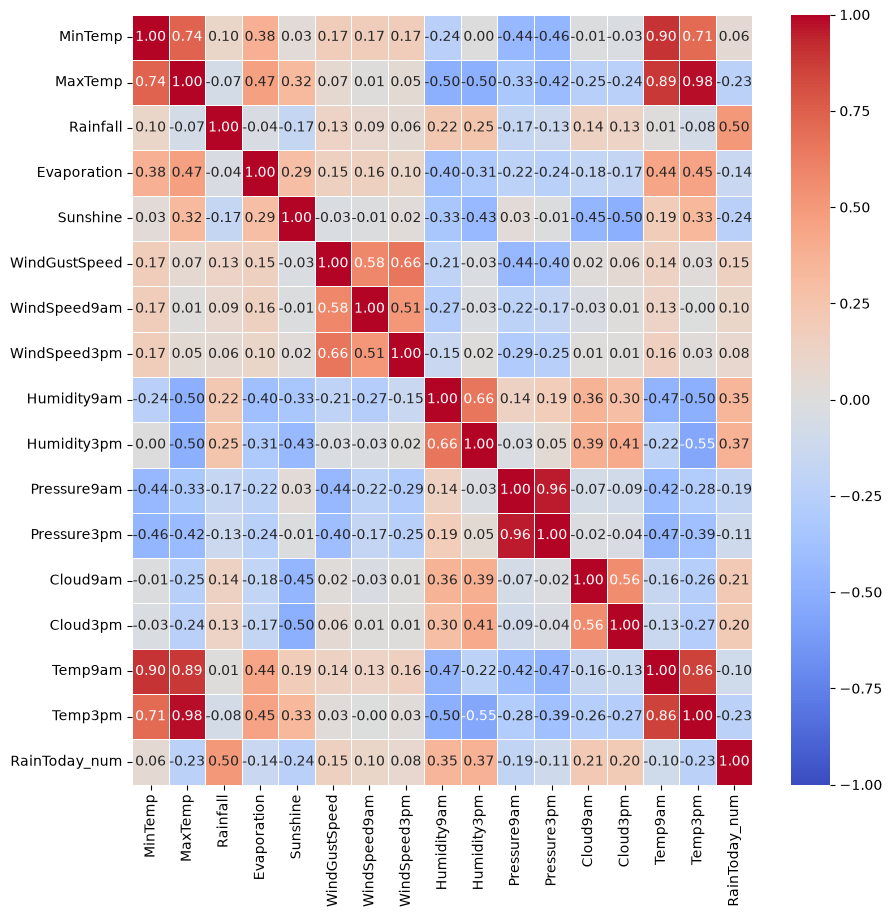

In [30]:
numerical_cols = ['MinTemp','MaxTemp','Rainfall','Evaporation','Sunshine','WindGustSpeed','WindSpeed9am','WindSpeed3pm','Humidity9am','Humidity3pm','Pressure9am','Pressure3pm','Cloud9am','Cloud3pm','Temp9am','Temp3pm','RainToday_num']
correlation = df[numerical_cols].corr()

plt.figure(figsize=(10 , 10))

sns.heatmap(correlation , annot= True , linewidths=0.5 ,fmt='0.2f' , cmap='coolwarm' ,vmin=-1, vmax=1,)

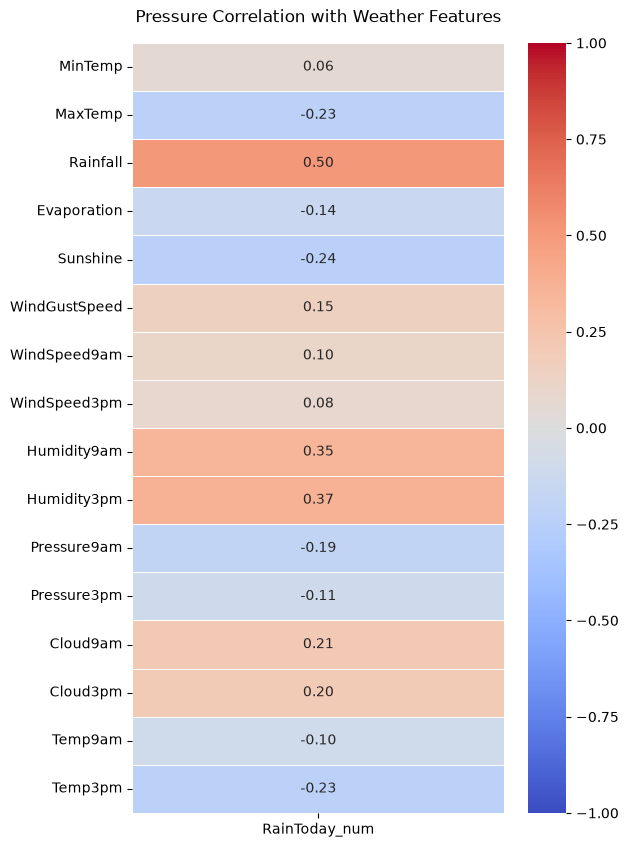

In [31]:
target_cols = ['RainToday_num']
feature_cols = [col for col in numerical_cols if col not in target_cols]

pressure_corr = correlation.loc[feature_cols, target_cols]

plt.figure(figsize=(6, 10))

sns.heatmap(
    pressure_corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5,
    vmin=-1,
    vmax=1
)

plt.title('Pressure Correlation with Weather Features', fontsize=12, pad=15)
plt.show()

In [32]:
print(df[df["RainToday"] == "Yes"]["Rainfall"].min())
print(df[df["RainToday"] == "No"]["Rainfall"].max())

1.1
1.0


In [33]:
condission = np.where(df["Rainfall"] > 1.0 ,"Yes" , "No")
df["RainToday"] = df["RainToday"].fillna(pd.Series(condission , index = df.index))


In [34]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 142193 entries, 0 to 142192
Data columns (total 28 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   Date           142193 non-null  datetime64[us]
 1   Location       142193 non-null  str           
 2   MinTemp        142193 non-null  float64       
 3   MaxTemp        142193 non-null  float64       
 4   Rainfall       142193 non-null  float64       
 5   Evaporation    142193 non-null  float64       
 6   Sunshine       142193 non-null  float64       
 7   WindGustDir    142193 non-null  str           
 8   WindGustSpeed  142193 non-null  float64       
 9   WindDir9am     142193 non-null  str           
 10  WindDir3pm     142193 non-null  str           
 11  WindSpeed9am   142193 non-null  float64       
 12  WindSpeed3pm   142193 non-null  float64       
 13  Humidity9am    142193 non-null  float64       
 14  Humidity3pm    142193 non-null  float64       
 15  Pressure9am

In [35]:
df.isnull().sum()

Date                 0
Location             0
MinTemp              0
MaxTemp              0
Rainfall             0
Evaporation          0
Sunshine             0
WindGustDir          0
WindGustSpeed        0
WindDir9am           0
WindDir3pm           0
WindSpeed9am         0
WindSpeed3pm         0
Humidity9am          0
Humidity3pm          0
Pressure9am      11781
Pressure3pm      11781
Cloud9am             0
Cloud3pm             0
Temp9am              0
Temp3pm              0
RainToday            0
RainTomorrow         0
Year                 0
Month                0
Day                  0
Season               0
RainToday_num     1406
dtype: int64

In [36]:
df.columns

Index(['Date', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation',
       'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm',
       'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm',
       'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am',
       'Temp3pm', 'RainToday', 'RainTomorrow', 'Year', 'Month', 'Day',
       'Season', 'RainToday_num'],
      dtype='str')

In [37]:
print(df[['Pressure9am', 'Pressure3pm']].isna().sum())

print("-----------------------")

missing_by_location = df.groupby('Location')['Pressure9am'].apply(lambda x: x.isna().sum())
print(missing_by_location.sort_values(ascending=False))

print("-----------------------")

total_by_location = df.groupby('Location')['Pressure9am'].size()
pct_missing = (missing_by_location / total_by_location * 100).sort_values(ascending=False)
print(pct_missing.head(15))

Pressure9am    11781
Pressure3pm    11781
dtype: int64
-----------------------
Location
Penrith             2964
Newcastle           2955
SalmonGums          2955
MountGinini         2907
BadgerysCreek          0
Albany                 0
Albury                 0
AliceSprings           0
Cairns                 0
Canberra               0
Cobar                  0
CoffsHarbour           0
Dartmoor               0
Ballarat               0
Bendigo                0
Brisbane               0
Adelaide               0
Katherine              0
Hobart                 0
GoldCoast              0
Darwin                 0
Mildura                0
MelbourneAirport       0
MountGambier           0
Launceston             0
Moree                  0
Nhil                   0
NorfolkIsland          0
NorahHead              0
Nuriootpa              0
PearceRAAF             0
Perth                  0
Melbourne              0
PerthAirport           0
Portland               0
Richmond               0
Sale        

In [38]:
df.dropna(subset = ["Pressure9am" , "Pressure3pm"] , inplace = True)

In [39]:
df.info()

<class 'pandas.DataFrame'>
Index: 130412 entries, 0 to 142192
Data columns (total 28 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   Date           130412 non-null  datetime64[us]
 1   Location       130412 non-null  str           
 2   MinTemp        130412 non-null  float64       
 3   MaxTemp        130412 non-null  float64       
 4   Rainfall       130412 non-null  float64       
 5   Evaporation    130412 non-null  float64       
 6   Sunshine       130412 non-null  float64       
 7   WindGustDir    130412 non-null  str           
 8   WindGustSpeed  130412 non-null  float64       
 9   WindDir9am     130412 non-null  str           
 10  WindDir3pm     130412 non-null  str           
 11  WindSpeed9am   130412 non-null  float64       
 12  WindSpeed3pm   130412 non-null  float64       
 13  Humidity9am    130412 non-null  float64       
 14  Humidity3pm    130412 non-null  float64       
 15  Pressure9am    1

<Axes: >

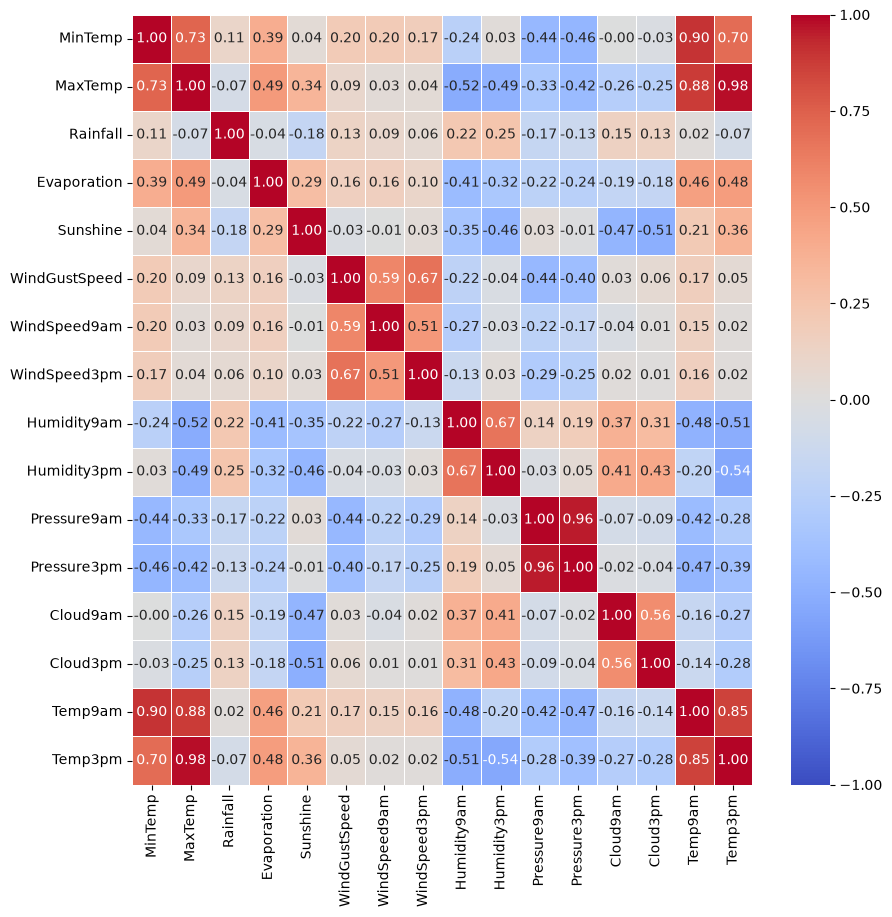

In [40]:
numerical_cols = ['MinTemp','MaxTemp','Rainfall','Evaporation','Sunshine','WindGustSpeed','WindSpeed9am','WindSpeed3pm','Humidity9am','Humidity3pm','Pressure9am','Pressure3pm','Cloud9am','Cloud3pm','Temp9am','Temp3pm']
correlation = df[numerical_cols].corr()

plt.figure(figsize=(10 , 10))

sns.heatmap(correlation , annot= True , linewidths=0.5 ,fmt='0.2f' , cmap='coolwarm' ,vmin=-1, vmax=1,)

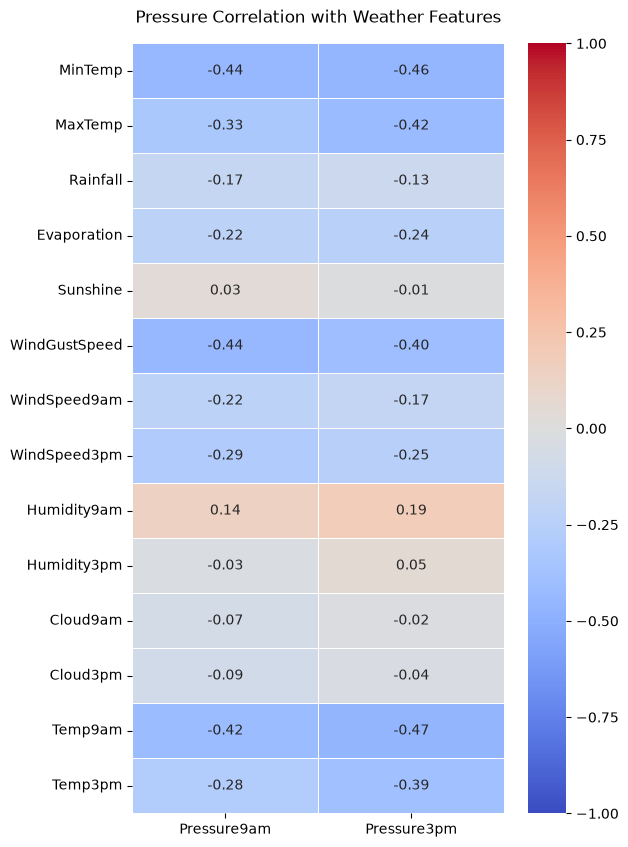

In [41]:
target_cols = ['Pressure9am', 'Pressure3pm']
feature_cols = [col for col in numerical_cols if col not in target_cols]

pressure_corr = correlation.loc[feature_cols, target_cols]

plt.figure(figsize=(6, 10))

sns.heatmap(
    pressure_corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5,
    vmin=-1,
    vmax=1
)

plt.title('Pressure Correlation with Weather Features', fontsize=12, pad=15)
plt.show()

## أخيراا

In [42]:
df.drop("RainToday_num", axis=1 , inplace= True)

In [43]:
df.duplicated().sum()

np.int64(0)

In [44]:
df.info()

<class 'pandas.DataFrame'>
Index: 130412 entries, 0 to 142192
Data columns (total 27 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   Date           130412 non-null  datetime64[us]
 1   Location       130412 non-null  str           
 2   MinTemp        130412 non-null  float64       
 3   MaxTemp        130412 non-null  float64       
 4   Rainfall       130412 non-null  float64       
 5   Evaporation    130412 non-null  float64       
 6   Sunshine       130412 non-null  float64       
 7   WindGustDir    130412 non-null  str           
 8   WindGustSpeed  130412 non-null  float64       
 9   WindDir9am     130412 non-null  str           
 10  WindDir3pm     130412 non-null  str           
 11  WindSpeed9am   130412 non-null  float64       
 12  WindSpeed3pm   130412 non-null  float64       
 13  Humidity9am    130412 non-null  float64       
 14  Humidity3pm    130412 non-null  float64       
 15  Pressure9am    1

## Handling outliers

In [45]:
top_rainfall = df.nlargest(10 , "Rainfall")
print(top_rainfall[['Date', 'Rainfall', 'WindGustSpeed', 'Pressure9am', 'Pressure3pm', 'Humidity9am']])

             Date  Rainfall  WindGustSpeed  Pressure9am  Pressure3pm  \
34002  2009-11-07     371.0           51.0       1026.6       1025.9   
40549  2011-02-16     367.6           83.0        996.3        996.0   
24341  2009-01-12     278.4           59.0       1003.5        999.6   
25094  2011-02-04     268.6           37.0       1011.1       1009.3   
26466  2015-02-08     247.2           44.0       1014.2       1011.4   
114433 2009-02-03     236.8           48.0       1003.8       1000.6   
132762 2016-01-06     225.0           80.0       1008.5       1008.8   
36260  2016-06-05     219.6           70.0        998.5        993.7   
42641  2017-02-05     210.6           67.0       1002.5        999.9   
35117  2013-01-28     208.5           65.0       1006.8       1004.2   

        Humidity9am  
34002          93.0  
40549          98.0  
24341          96.0  
25094          82.0  
26466         100.0  
114433         98.0  
132762         95.0  
36260          90.0  
42641    

In [46]:
# 2) استخدم IQR كأداة اكتشاف بس (مش تعديل)
Q1 = df['Rainfall'].quantile(0.25)
Q3 = df['Rainfall'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

suspicious = df[df['Rainfall'] > upper_bound]
print(f"عدد القيم المشكوك فيها: {len(suspicious)}")
print(suspicious[['Date', 'Rainfall', 'WindGustSpeed', 'Pressure9am']].sort_values('Rainfall', ascending=False))

عدد القيم المشكوك فيها: 26248
             Date  Rainfall  WindGustSpeed  Pressure9am
34002  2009-11-07     371.0           51.0       1026.6
40549  2011-02-16     367.6           83.0        996.3
24341  2009-01-12     278.4           59.0       1003.5
25094  2011-02-04     268.6           37.0       1011.1
26466  2015-02-08     247.2           44.0       1014.2
...           ...       ...            ...          ...
127167 2015-12-05       1.6           35.0       1012.4
29163  2013-03-29       1.6           37.0       1018.9
76658  2012-11-29       1.6           37.0       1016.9
110951 2016-05-09       1.6           43.0       1008.8
55035  2013-03-19       1.6           33.0       1024.7

[26248 rows x 4 columns]


In [47]:
# 3) فلترة إضافية: هل القيمة دي "منطقية فيزيائيًا"؟
# مثال: لو Rainfall عالي جدًا لكن مفيش سحاب (Cloud9am/3pm واطي) → إشارة قوية على خطأ إدخال
inconsistent = suspicious[(suspicious['Cloud9am'] < 3) & (suspicious['Cloud3pm'] < 3)]
print(inconsistent[['Date', 'Rainfall', 'Cloud9am', 'Cloud3pm']])

             Date  Rainfall  Cloud9am  Cloud3pm
3166   2009-02-15       1.8       1.0       0.0
3211   2009-04-01       7.2       2.0       1.0
3279   2009-06-08       6.2       1.0       2.0
3371   2009-09-08      15.0       1.0       1.0
3568   2010-03-24      13.4       1.0       1.0
...           ...       ...       ...       ...
141275 2014-12-11       6.6       0.0       0.0
141308 2015-01-13       7.0       1.0       1.0
141645 2015-12-16       2.6       0.0       0.5
141875 2016-08-02       7.6       0.0       1.0
141892 2016-08-19       6.2       2.0       1.0

[758 rows x 4 columns]


In [48]:
symmetric_cols = [
    'MinTemp', 'MaxTemp', 'Temp9am', 'Temp3pm', 
    'Pressure9am', 'Pressure3pm', 'Humidity9am'
]

for col in symmetric_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    
    lower_bound = q1 - (1.5 * iqr)
    upper_bound = q3 + (1.5 * iqr)
    
    df[col] = np.clip(df[col], lower_bound, upper_bound)

In [49]:
skewed_cols = [
    'Rainfall', 'Evaporation', 'WindGustSpeed', 
    'WindSpeed9am', 'WindSpeed3pm'
]

for col in skewed_cols:
    upper_limit = df[col].quantile(0.99)

    df[col] = np.clip(df[col], a_min=df[col].min(), a_max=upper_limit)

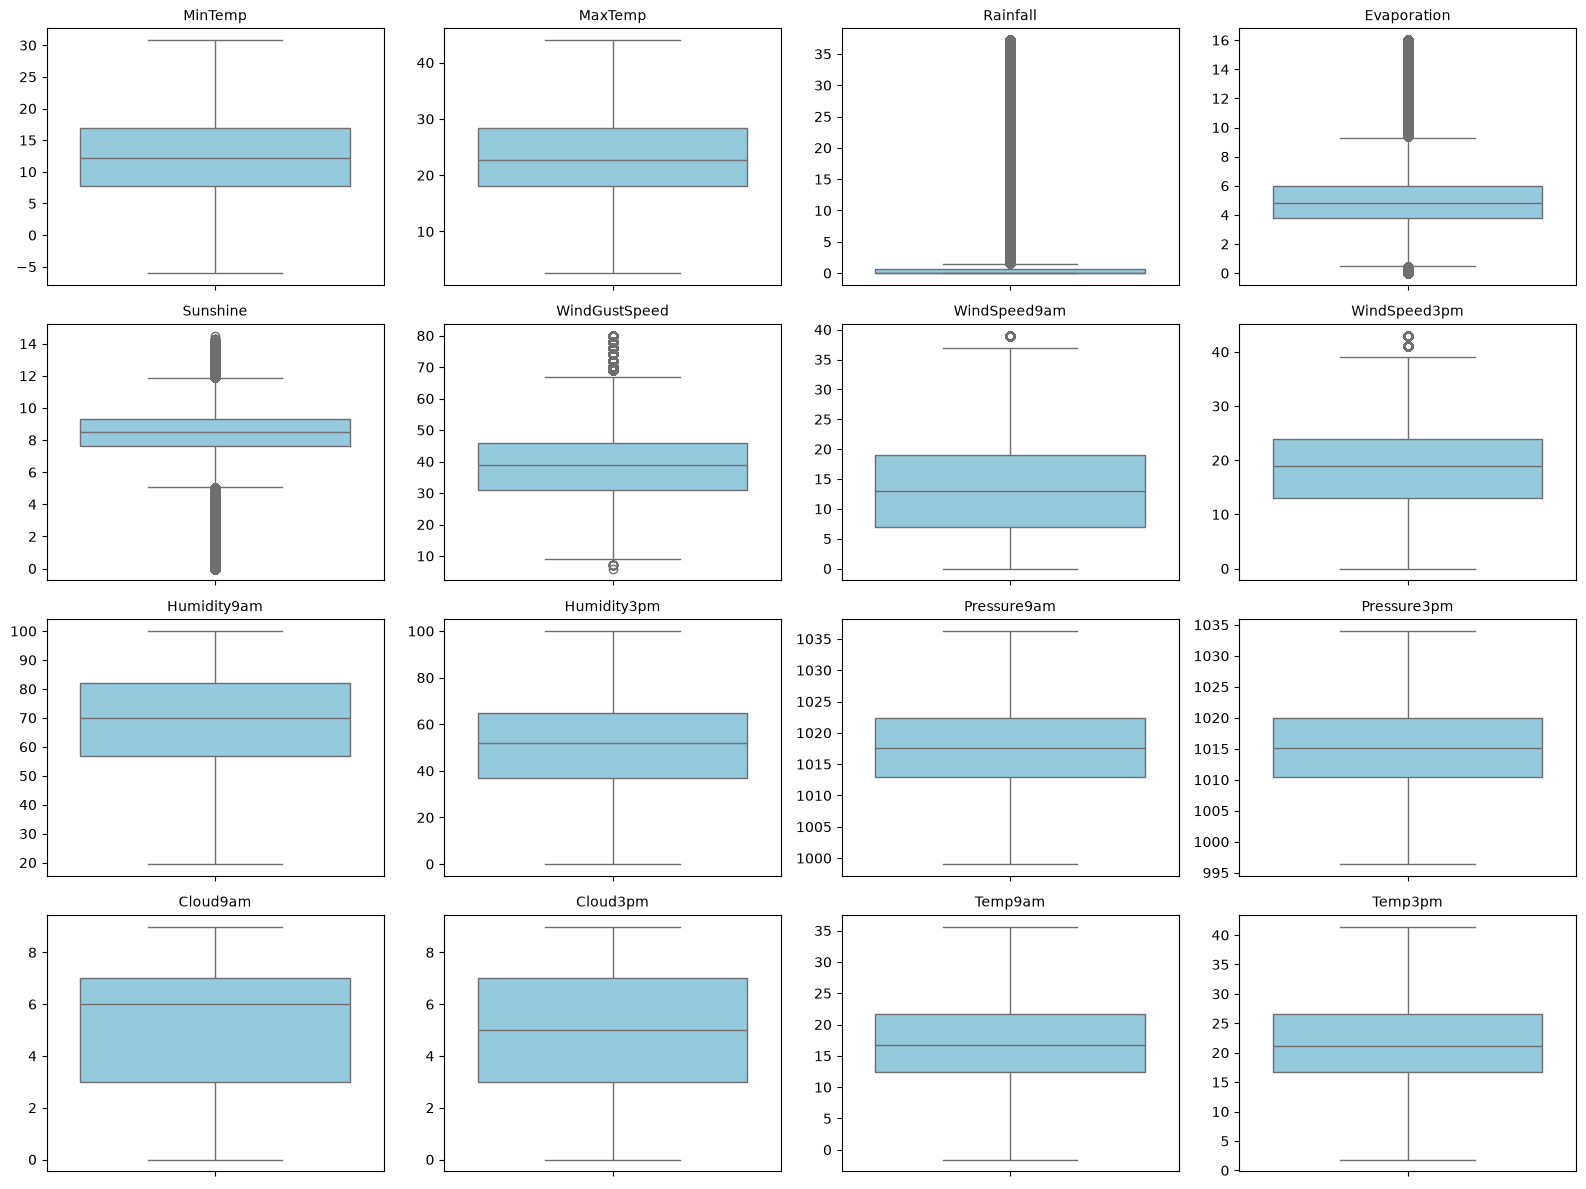

In [51]:
import math

num_cols_count = len(num_clolumns)

n_cols = 4
n_rows = math.ceil(num_cols_count / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3))

axes = axes.flatten()

for i, col in enumerate(num_clolumns):
    sns.boxplot(y=df[col], ax=axes[i], color='skyblue')
    axes[i].set_title(col, fontsize=10)
    axes[i].set_ylabel('')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()